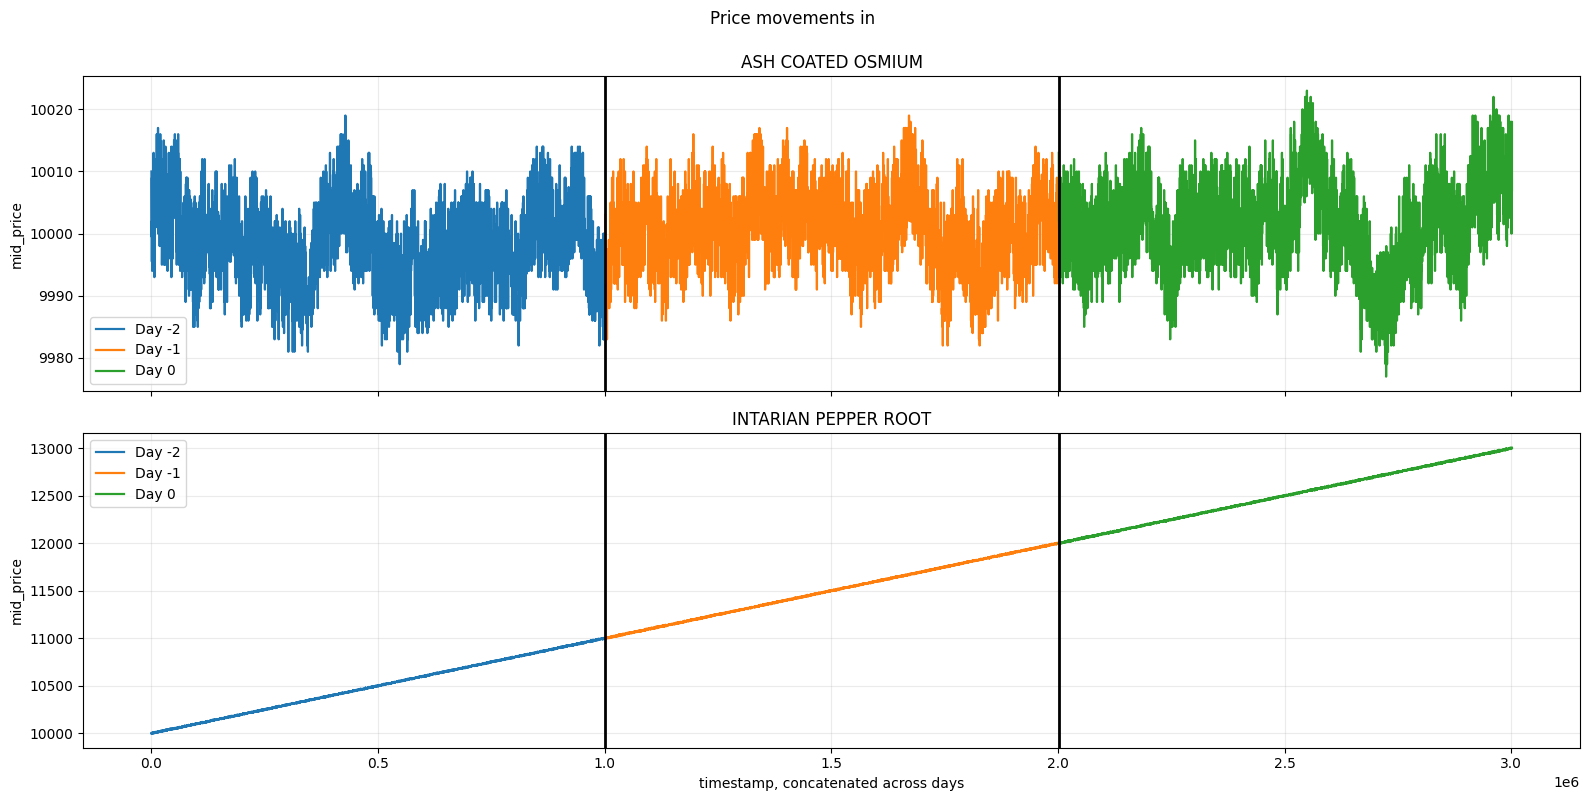

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 1
ROUND_FOLDER = Path(".")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

LEVELS = (1, 2, 3)


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    notebook_dir = Path.cwd()
    for root in (notebook_dir, notebook_dir.parent):
        candidate = root / path
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find data file: {path}")


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


In [4]:
# Distribution of raw alt_mid_price changes from one tick to the next + autocorrelation.
asset = "ASH_COATED_OSMIUM"
prices_csv = "prices_round_1_day_-1.csv"

sub = load_prices(prices_csv)
sub = (
    sub[sub["product"] == asset]
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

# Drop the very first tick before constructing alt_mid_price-derived diagnostics.
sub = sub.iloc[1:].reset_index(drop=True)


def reconstruct_side_levels(frame: pd.DataFrame, side: str) -> pd.DataFrame:
    value_cols = [
        col
        for col in [f"{side}_price_1", f"{side}_price_2", f"{side}_price_3"]
        if col in frame.columns
    ]

    far_values: list[float | None] = []
    mid_values: list[float | None] = []
    far_state: float | None = None
    mid_state: float | None = None

    for _, row in frame.iterrows():
        values = []
        for col in value_cols:
            value = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(value) and value > 0:
                values.append(float(value))

        values.sort()

        far_value = far_state
        mid_value = mid_state

        if values:
            pair_found = False

            if side == "ask" and len(values) >= 2:
                candidate_mid = values[-2]
                candidate_far = values[-1]
                if candidate_far - candidate_mid <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True
            elif side == "bid" and len(values) >= 2:
                candidate_far = values[0]
                candidate_mid = values[1]
                if candidate_mid - candidate_far <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True

            if not pair_found:
                candidate = values[-1] if side == "ask" else values[0]

                if far_state is None or mid_state is None:
                    far_value = candidate
                    mid_value = candidate
                elif abs(candidate - far_state) <= 1:
                    far_value = candidate
                elif abs(candidate - mid_state) <= 1:
                    mid_value = candidate

        far_state = far_value
        mid_state = mid_value
        far_values.append(far_value)
        mid_values.append(mid_value)

    return pd.DataFrame({f"far_{side}": far_values, f"mid_{side}": mid_values})


bid_levels = reconstruct_side_levels(sub, "bid")
ask_levels = reconstruct_side_levels(sub, "ask")
sub = pd.concat([sub, bid_levels, ask_levels], axis=1)
sub["alt_mid_price"] = sub[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)

raw_change = sub["alt_mid_price"].diff().dropna()



In [5]:
from pathlib import Path
import re

import pandas as pd

PRODUCT = "INTARIAN_PEPPER_ROOT"
DAY_FILE_GLOB = "trades_round_1_day_*.csv"


def infer_side(df: pd.DataFrame) -> pd.Series:
    """
    Infer trade side:
    - If SUBMISSION is present in buyer/seller, use that explicitly.
    - Otherwise fall back to tick rule on trade price (up-tick=buy, down-tick=sell).
    """
    buyer = df.get("buyer", pd.Series(index=df.index, dtype="object")).fillna("").astype(str)
    seller = df.get("seller", pd.Series(index=df.index, dtype="object")).fillna("").astype(str)

    side = pd.Series(index=df.index, dtype="object")
    side.loc[buyer == "SUBMISSION"] = "buy"
    side.loc[seller == "SUBMISSION"] = "sell"

    unresolved = side.isna()
    if unresolved.any():
        px = pd.to_numeric(df["price"], errors="coerce")
        delta = px.diff()

        tick_side = pd.Series(index=df.index, dtype="object")
        tick_side.loc[delta > 0] = "buy"
        tick_side.loc[delta < 0] = "sell"
        tick_side = tick_side.ffill()

        side.loc[unresolved] = tick_side.loc[unresolved]

    return side


def analyze_sell_to_next_buy(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    After a sell, find the next buy and compute distances.
    If two sells are consecutive, skip the second sell.
    """
    df = df.sort_values(["timestamp", "price", "quantity"]).reset_index(drop=True)
    df["side"] = infer_side(df)
    df = df[df["side"].isin(["buy", "sell"])].reset_index(drop=True)

    pair_rows = []
    n = len(df)

    for i in range(n):
        if df.at[i, "side"] != "sell":
            continue

        # Skip second sell in a row.
        if i > 0 and df.at[i - 1, "side"] == "sell":
            continue

        # Find next buy.
        j = i + 1
        while j < n and df.at[j, "side"] != "buy":
            j += 1

        if j >= n:
            continue

        sell_price = float(df.at[i, "price"])
        buy_price = float(df.at[j, "price"])
        sell_ts = int(df.at[i, "timestamp"])
        buy_ts = int(df.at[j, "timestamp"])

        pair_rows.append(
            {
                "sell_idx": i,
                "buy_idx": j,
                "sell_ts": sell_ts,
                "buy_ts": buy_ts,
                "sell_price": sell_price,
                "buy_price": buy_price,
                "price_distance": buy_price - sell_price,
                "timestamp_distance": buy_ts - sell_ts,
                "trade_distance": j - i,
            }
        )

    pairs = pd.DataFrame(pair_rows)

    if pairs.empty:
        summary = pd.DataFrame(
            [
                {
                    "pairs": 0,
                    "avg_price_distance": pd.NA,
                    "avg_timestamp_distance": pd.NA,
                    "avg_trade_distance": pd.NA,
                }
            ]
        )
    else:
        summary = pd.DataFrame(
            [
                {
                    "pairs": len(pairs),
                    "avg_price_distance": pairs["price_distance"].mean(),
                    "avg_timestamp_distance": pairs["timestamp_distance"].mean(),
                    "avg_trade_distance": pairs["trade_distance"].mean(),
                }
            ]
        )

    return summary, pairs


round_dir = Path(".")
trade_files = sorted(round_dir.glob(DAY_FILE_GLOB), key=lambda p: int(re.search(r"day_(-?\d+)", p.name).group(1)))

results = []
all_pairs = {}

for f in trade_files:
    day_match = re.search(r"day_(-?\d+)", f.name)
    if not day_match:
        continue
    day = int(day_match.group(1))

    t = pd.read_csv(f, sep=";")
    t = t[t["symbol"] == PRODUCT].copy()

    summary, pairs = analyze_sell_to_next_buy(t)
    summary.insert(0, "day", day)
    results.append(summary)
    all_pairs[day] = pairs

summary_by_day = pd.concat(results, ignore_index=True).sort_values("day").reset_index(drop=True)
print(f"Product: {PRODUCT}")
display(summary_by_day)

# Optional: inspect detailed pair rows for any day, e.g. all_pairs[-1].head(10)


Product: INTARIAN_PEPPER_ROOT


,day,pairs,avg_price_distance,avg_timestamp_distance,avg_trade_distance
0,-2,102,10.166667,3740.196078,1.245098
1,-1,93,8.591398,3455.913978,1.118280
2,0,98,10.265306,3503.061224,1.234694


In [8]:
def analyze_trade_distribution_by_mid_price(
    trades: str | pd.DataFrame,
    alt_mid_price: float,
    product: str | None = None,
    figsize: tuple = (14, 5),
):
    """
    Analyze the distribution of trade sizes split by whether trades occurred
    above or below the alt_mid_price.

    Parameters
    ----------
    trades : str or pd.DataFrame
        Either a filename/path to load or a DataFrame with columns:
        'price', 'quantity'. Optionally 'symbol' or 'product' to filter.
    alt_mid_price : float
        Threshold price to split trades.
    product : str, optional
        If provided, filter trades to this product/symbol first.
    figsize : tuple
        Figure size for plots.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame, plt.Figure]
        - above_mid: stats for trades at price >= alt_mid_price
        - below_mid: stats for trades at price < alt_mid_price
        - fig: matplotlib figure with distribution plots
    """
    # Load trades if string path provided
    if isinstance(trades, str):
        trades = pd.read_csv(trades, sep=";")
    
    # Normalize column names
    trades = trades.copy()
    trades.columns = [str(c).strip().lower() for c in trades.columns]

    # Filter by product if specified
    if product is not None:
        symbol_col = "symbol" if "symbol" in trades.columns else "product"
        if symbol_col in trades.columns:
            trades = trades[trades[symbol_col].astype(str).str.upper() == product.upper()].copy()

    # Ensure numeric columns
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades["quantity"] = pd.to_numeric(trades["quantity"], errors="coerce")

    # Drop rows with NaN price or quantity
    trades = trades.dropna(subset=["price", "quantity"])

    # Split by mid price
    above_mid = trades[trades["price"] >= alt_mid_price]
    below_mid = trades[trades["price"] < alt_mid_price]

    # Compute statistics
    above_stats = {
        "count": len(above_mid),
        "size_mean": above_mid["quantity"].mean(),
        "size_median": above_mid["quantity"].median(),
        "size_std": above_mid["quantity"].std(),
        "size_min": above_mid["quantity"].min(),
        "size_max": above_mid["quantity"].max(),
        "total_volume": above_mid["quantity"].sum(),
    }

    below_stats = {
        "count": len(below_mid),
        "size_mean": below_mid["quantity"].mean(),
        "size_median": below_mid["quantity"].median(),
        "size_std": below_mid["quantity"].std(),
        "size_min": below_mid["quantity"].min(),
        "size_max": below_mid["quantity"].max(),
        "total_volume": below_mid["quantity"].sum(),
    }

    above_df = pd.DataFrame([above_stats], index=["above_mid"])
    below_df = pd.DataFrame([below_stats], index=["below_mid"])

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    if len(above_mid) > 0:
        axes[0].hist(
            above_mid["quantity"],
            bins=30,
            color="green",
            alpha=0.7,
            edgecolor="black",
        )
        axes[0].set_title(f"Trade sizes >= {alt_mid_price:.0f} (n={len(above_mid)})")
        axes[0].set_xlabel("Trade quantity")
        axes[0].set_ylabel("Frequency")
        axes[0].grid(True, alpha=0.3)

    if len(below_mid) > 0:
        axes[1].hist(
            below_mid["quantity"],
            bins=30,
            color="red",
            alpha=0.7,
            edgecolor="black",
        )
        axes[1].set_title(f"Trade sizes < {alt_mid_price:.0f} (n={len(below_mid)})")
        axes[1].set_xlabel("Trade quantity")
        axes[1].set_ylabel("Frequency")
        axes[1].grid(True, alpha=0.3)

    fig.suptitle("Trade Size Distribution Split by alt_mid_price", fontsize=14, fontweight="bold")
    plt.tight_layout()

    return above_df, below_df, fig


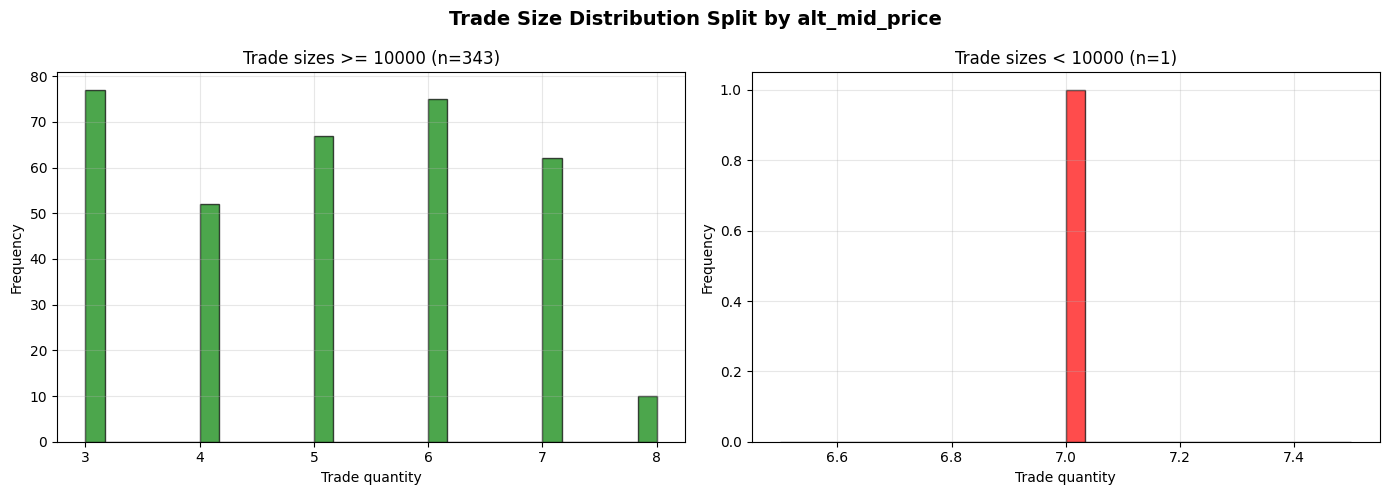

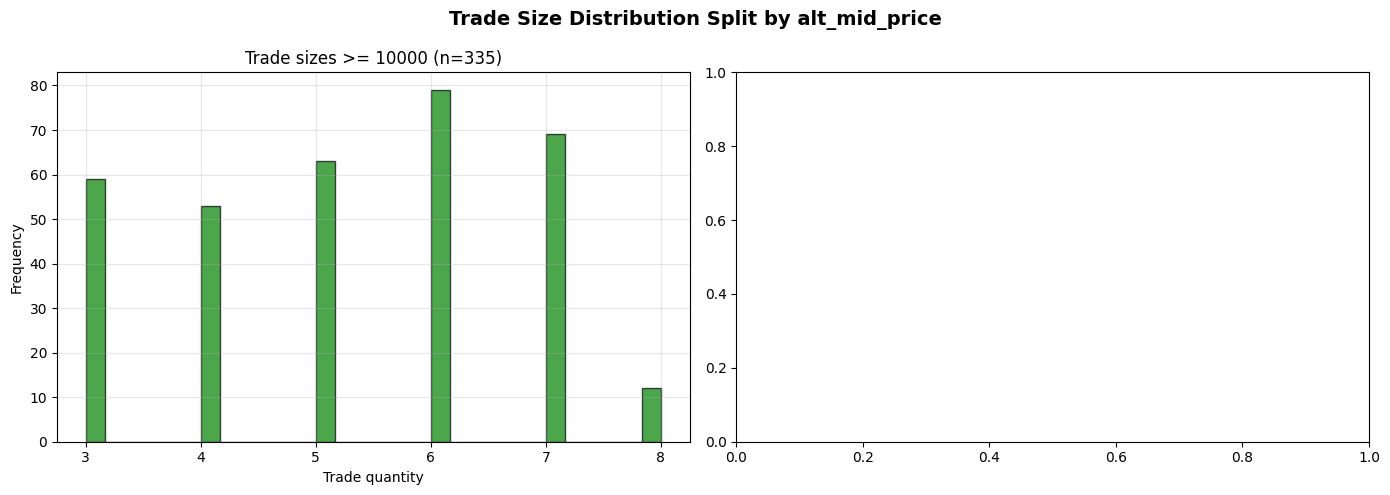

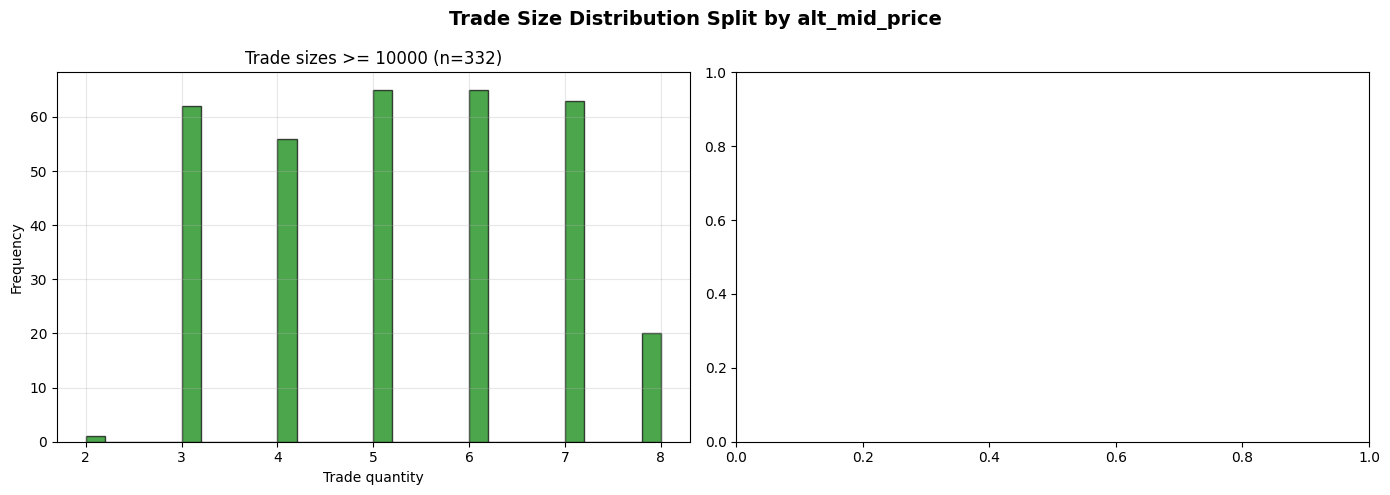

In [9]:
above_df, below_df, fig = analyze_trade_distribution_by_mid_price(
    trades="trades_round_1_day_-2.csv",
    alt_mid_price=10000,
    product="INTARIAN_PEPPER_ROOT"
)
above_df, below_df, fig = analyze_trade_distribution_by_mid_price(
    trades="trades_round_1_day_-1.csv",
    alt_mid_price=10000,
    product="INTARIAN_PEPPER_ROOT"
)
above_df, below_df, fig = analyze_trade_distribution_by_mid_price(
    trades="trades_round_1_day_0.csv",
    alt_mid_price=10000,
    product="INTARIAN_PEPPER_ROOT"
)